# Car Price Prediction with Machine Learning

**Oasis Infobyte Data Science Internship — Task 3**

**Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

## Steps Included

1. Import Required Libraries
2. Load the Dataset
3. Understand the Dataset
4. Data Cleaning
5. Handle Missing Values
6. Remove Duplicate Records
7. Handle Inconsistent Categorical Values
8. Feature Engineering
9. Extract Car Brand
10. Calculate Car Age
11. Exploratory Data Analysis
12. Analyze Selling Price Distribution
13. Analyze Price vs Fuel Type
14. Analyze Price vs Car Age
15. Additional Data Visualizations
16. Encode Categorical Variables
17. Prepare Features and Target
18. Feature Correlation Analysis
19. Split the Dataset into Training and Testing Sets
20. Train Linear Regression Model
21. Train Random Forest Regressor Model
22. Optional: Train Gradient Boosting Regressor
23. Make Predictions
24. Evaluate Model Performance
25. Compare Regression Models
26. Select the Best-Performing Model
27. Analyze Feature Importance
28. Final Model Interpretation
29. Conclusion

## 1. Import Required Libraries

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning - preprocessing and data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Machine learning - regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

In [3]:
# Import the file upload utility from Google Colab
from google.colab import files

# Upload the dataset
uploaded = files.upload()

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO.csv


In [4]:
# Get the uploaded file name
file_name = next(iter(uploaded))

# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_name)

# Display the first five rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## 3. Understand the Dataset

In [5]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display the first five rows
print("\nFirst Five Rows:")
display(df.head())

# Display the last five rows
print("\nLast Five Rows:")
display(df.tail())

# Display dataset information
print("\nDataset Information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

Dataset Shape: (4340, 8)

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

First Five Rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner



Last Five Rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB

Descriptive Statistics:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


## 4. Data Cleaning

In [6]:
# Check for missing values in each column
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate records
print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())

# Display unique values in categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("\nUnique Values in Categorical Columns:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Number of Duplicate Records:
763

Unique Values in Categorical Columns:

name:
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']

fuel:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


## 5. Handle Missing Values

In [7]:
# Check the number of missing values in each column
missing_values = df.isnull().sum()

print("Missing Values Before Handling:")
print(missing_values)

# Check whether the dataset contains any missing values
if missing_values.sum() == 0:
    print("\nNo missing values were found. No imputation or row removal is required.")
else:
    print("\nMissing values were found. Handling them based on the column type...")

    # Handle missing numerical values using the median
    numerical_columns = df.select_dtypes(include=np.number).columns

    for column in numerical_columns:
        if df[column].isnull().sum() > 0:
            df[column] = df[column].fillna(df[column].median())

    # Handle missing categorical values using the mode
    categorical_columns = df.select_dtypes(include="object").columns

    for column in categorical_columns:
        if df[column].isnull().sum() > 0:
            df[column] = df[column].fillna(df[column].mode()[0])

# Verify missing values after handling
print("\nMissing Values After Handling:")
print(df.isnull().sum())

Missing Values Before Handling:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

No missing values were found. No imputation or row removal is required.

Missing Values After Handling:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


## 6. Remove Duplicate Records

In [8]:
# Count duplicate records before removal
duplicate_count = df.duplicated().sum()

print("Duplicate Records Before Removal:", duplicate_count)

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

# Display the new dataset shape
print("\nDataset Shape After Removing Duplicates:", df.shape)

# Verify that duplicates have been removed
print("\nDuplicate Records After Removal:", df.duplicated().sum())

Duplicate Records Before Removal: 763

Dataset Shape After Removing Duplicates: (3577, 8)

Duplicate Records After Removal: 0


## 7. Handle Inconsistent Categorical Values

In [9]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Remove leading/trailing spaces and standardize text formatting
for column in categorical_columns:
    df[column] = df[column].str.strip()

# Standardize categorical values where required
df["fuel"] = df["fuel"].str.title()
df["seller_type"] = df["seller_type"].str.title()
df["transmission"] = df["transmission"].str.title()
df["owner"] = df["owner"].str.title()

# Display unique values after standardization
print("Unique Values After Standardization:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Unique Values After Standardization:

name:
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']

fuel:
['Petrol' 'Diesel' 'Cng' 'Lpg' 'Electric']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


## 8. Feature Engineering

In [10]:
# Create a copy of the cleaned dataset for feature engineering
df = df.copy()

# Display the current columns before feature engineering
print("Columns before feature engineering:")
print(df.columns.tolist())

Columns before feature engineering:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


## 9. Extract Car Brand

In [11]:
  # Extract the car brand from the first word of the car name
df["brand"] = df["name"].str.split().str[0]

# Display the first few car names along with their extracted brands
display(df[["name", "brand"]].head(10))

# Display the unique car brands
print("\nNumber of Unique Brands:", df["brand"].nunique())

print("\nUnique Car Brands:")
print(sorted(df["brand"].unique()))

,name,brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Hyundai Xcent 1.2 Kappa S,Hyundai
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti



Number of Unique Brands: 29

Unique Car Brands:
['Ambassador', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'OpelCorsa', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']


## 10. Calculate Car Age

In [12]:
# Define the reference year
reference_year = 2026

# Calculate the age of each car
df["car_age"] = reference_year - df["year"]

# Display the year and calculated car age
display(df[["year", "car_age"]].head(10))

# Check the range of car ages
print("\nMinimum Car Age:", df["car_age"].min())
print("Maximum Car Age:", df["car_age"].max())

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12
5,2007,19
6,2016,10
7,2014,12
8,2015,11
9,2017,9



Minimum Car Age: 6
Maximum Car Age: 34


## 11. Exploratory Data Analysis

In [13]:
# Display the updated dataset information
print("Dataset Information After Feature Engineering:")
df.info()

# Display summary statistics for numerical features
print("\nNumerical Feature Summary:")
display(df.describe())

# Display the number of unique values in each column
print("\nNumber of Unique Values in Each Column:")
display(df.nunique())

Dataset Information After Feature Engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3577 non-null   object
 1   year           3577 non-null   int64 
 2   selling_price  3577 non-null   int64 
 3   km_driven      3577 non-null   int64 
 4   fuel           3577 non-null   object
 5   seller_type    3577 non-null   object
 6   transmission   3577 non-null   object
 7   owner          3577 non-null   object
 8   brand          3577 non-null   object
 9   car_age        3577 non-null   int64 
dtypes: int64(4), object(6)
memory usage: 279.6+ KB

Numerical Feature Summary:


,year,selling_price,km_driven,car_age
count,3577.000000,3.577000e+03,3577.000000,3577.000000
mean,2012.962538,4.739125e+05,69250.545709,13.037462
std,4.251759,5.093018e+05,47579.940016,4.251759
min,1992.000000,2.000000e+04,1.000000,6.000000
25%,2010.000000,2.000000e+05,36000.000000,10.000000
50%,2013.000000,3.500000e+05,60000.000000,13.000000
75%,2016.000000,6.000000e+05,90000.000000,16.000000
max,2020.000000,8.900000e+06,806599.000000,34.000000



Number of Unique Values in Each Column:


,0
name,1491
year,27
selling_price,445
km_driven,770
fuel,5
seller_type,3
transmission,2
owner,5
brand,29
car_age,27


## 12. Analyze Selling Price Distribution

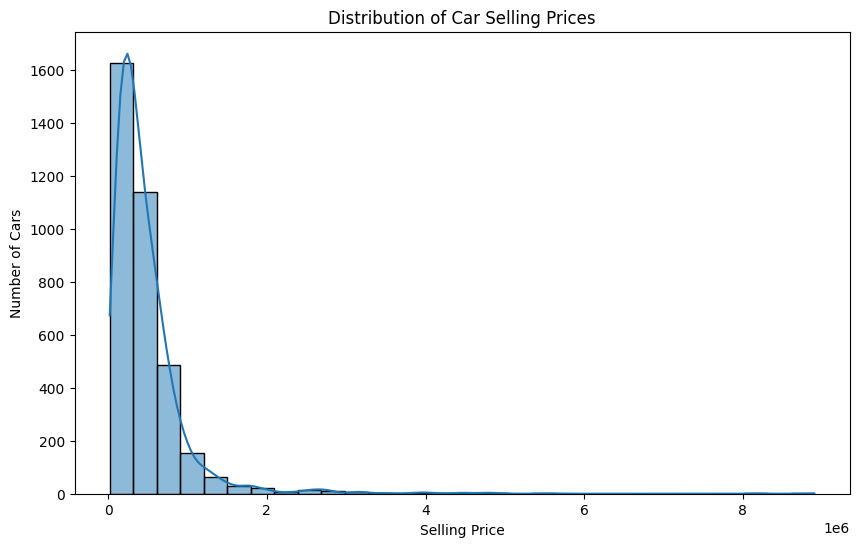

In [14]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Plot the distribution of selling prices
sns.histplot(
    df["selling_price"],
    bins=30,
    kde=True
)

# Add title and axis labels
plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

# Display the plot
plt.show()

###Observation: The selling-price distribution is strongly right-skewed. Most cars are concentrated at relatively lower prices, while a smaller number of cars have very high selling prices, creating a long right tail and several potential outliers.

## 13. Analyze Price vs Fuel Type

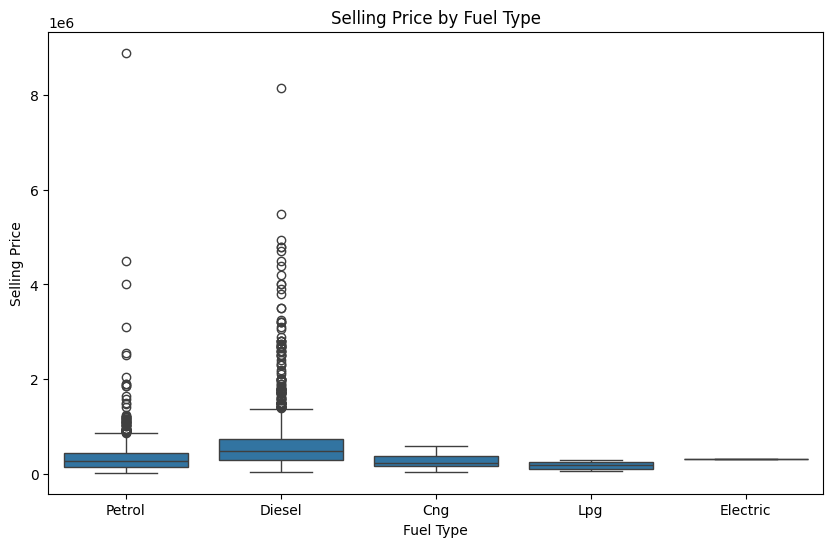

In [15]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a box plot of selling price by fuel type
sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

# Add title and axis labels
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

# Display the plot
plt.show()

### Observation: Diesel cars show a higher median selling price compared with Petrol and the other fuel categories. Petrol and Diesel also contain several high-price outliers. The Electric category has relatively few observations, so its distribution should be interpreted cautiously.

## 14. Analyze Price vs Car Age

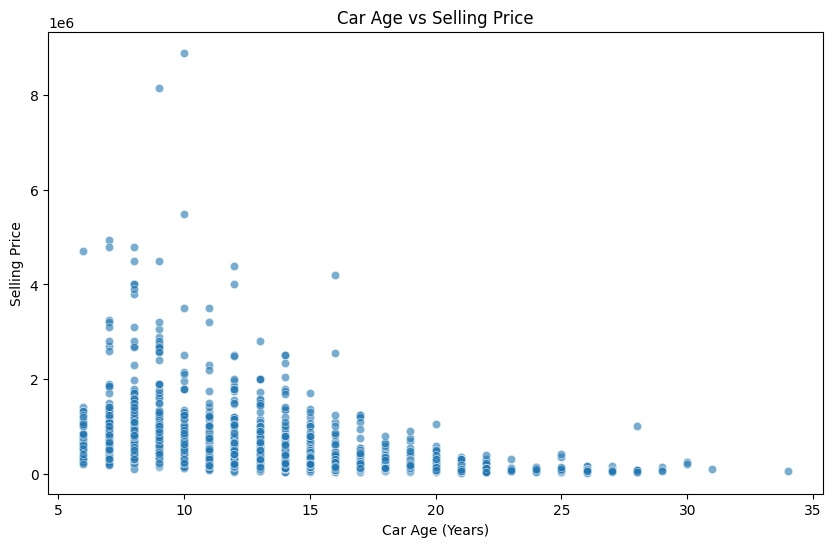

In [16]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot of car age against selling price
sns.scatterplot(
    data=df,
    x="car_age",
    y="selling_price",
    alpha=0.6
)

# Add title and axis labels
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

# Display the plot
plt.show()

### Observation: The scatter plot shows a general negative relationship between car age and selling price. Newer cars tend to have higher selling prices, while older cars are generally sold at lower prices. Some high-priced observations are visible among newer vehicles.

## 15. Additional Data Visualizations

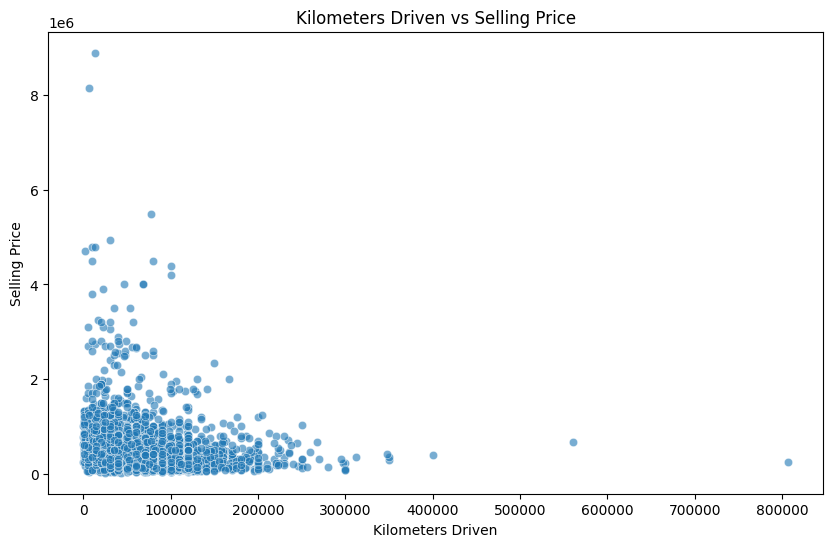

In [17]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot of kilometers driven against selling price
sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price",
    alpha=0.6
)

# Add title and axis labels
plt.title("Kilometers Driven vs Selling Price")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")

# Display the plot
plt.show()

### Observation: The plot shows a general negative relationship between kilometers driven and selling price. Cars with higher mileage are mostly concentrated at lower selling prices, although considerable variation and several high-price outliers are present.

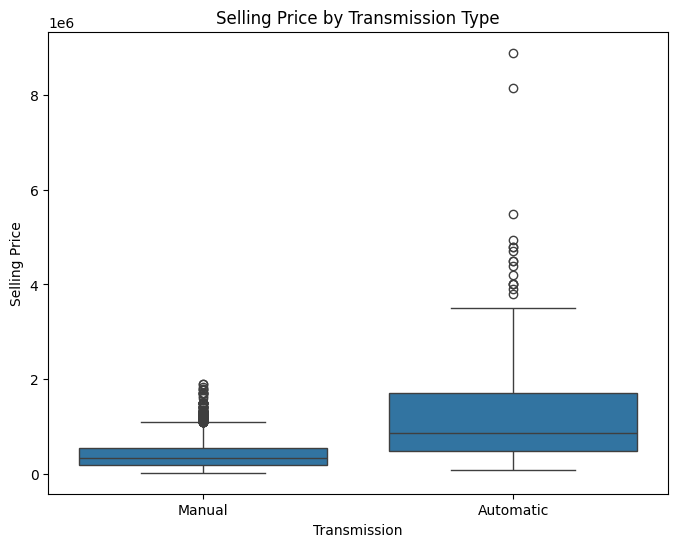

In [18]:
# Set the figure size
plt.figure(figsize=(8, 6))

# Create a box plot of selling price by transmission type
sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)

# Add title and axis labels
plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

# Display the plot
plt.show()

### Observation: Automatic cars have a higher median selling price and a wider price distribution compared with Manual cars. Both transmission categories contain outliers, with several particularly high-priced observations among Automatic vehicles.

## 16. Encode Categorical Variables

In [19]:
# Define categorical and numerical features
categorical_features = [
    "brand",
    "fuel",
    "seller_type",
    "transmission",
    "owner"
]

numerical_features = [
    "car_age",
    "km_driven"
]

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

print("\nOne-Hot Encoding and preprocessing setup completed.")

Categorical Features:
['brand', 'fuel', 'seller_type', 'transmission', 'owner']

Numerical Features:
['car_age', 'km_driven']

One-Hot Encoding and preprocessing setup completed.


## 17. Prepare Features and Target

In [20]:
# Define the target variable
y = df["selling_price"]

# Define the input features
X = df[
    [
        "brand",
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ]
]

# Display the feature columns
print("Feature Columns:")
print(X.columns.tolist())

# Display the target variable
print("\nTarget Variable:")
print("selling_price")

# Display the shape of X and y
print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

# Display the first five rows of the feature matrix
print("\nFirst Five Rows of Features:")
display(X.head())

# Display the first five target values
print("\nFirst Five Target Values:")
display(y.head())

Feature Columns:
['brand', 'car_age', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Target Variable:
selling_price

Feature Matrix Shape: (3577, 7)
Target Shape: (3577,)

First Five Rows of Features:


,brand,car_age,km_driven,fuel,seller_type,transmission,owner
0,Maruti,19,70000,Petrol,Individual,Manual,First Owner
1,Maruti,19,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,14,100000,Diesel,Individual,Manual,First Owner
3,Datsun,9,46000,Petrol,Individual,Manual,First Owner
4,Honda,12,141000,Diesel,Individual,Manual,Second Owner



First Five Target Values:


,selling_price
0,60000
1,135000
2,600000
3,250000
4,450000


## 18. Feature Correlation Analysis

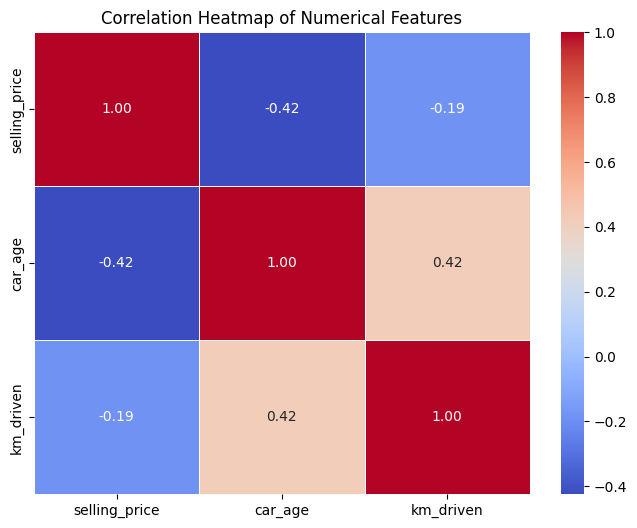

In [21]:
# Select numerical features for correlation analysis
correlation_data = df[
    ["selling_price", "car_age", "km_driven"]
]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Set the figure size
plt.figure(figsize=(8, 6))

# Create the correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

# Add title
plt.title("Correlation Heatmap of Numerical Features")

# Display the plot
plt.show()

## 19. Split the Dataset into Training and Testing Sets

In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the shapes of the resulting datasets
print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (2861, 7)
Testing Feature Shape: (716, 7)

Training Target Shape: (2861,)
Testing Target Shape: (716,)


In [23]:
# Fit the preprocessor using only the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

# Display the processed data shapes
print("Processed Training Data Shape:", X_train_processed.shape)
print("Processed Testing Data Shape:", X_test_processed.shape)

Processed Training Data Shape: (2861, 43)
Processed Testing Data Shape: (716, 43)


## 20. Train Linear Regression Model

In [24]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the processed training data
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 21. Train Random Forest Regressor Model

In [25]:
# Create the Random Forest Regressor model
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model using the processed training data
random_forest_model.fit(X_train_processed, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## 22. Optional: Train Gradient Boosting Regressor

In [26]:
# Import Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting Regressor model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train the model using the processed training data
gradient_boosting_model.fit(X_train_processed, y_train)

print("Gradient Boosting Regressor model trained successfully.")

Gradient Boosting Regressor model trained successfully.


## 23. Make Predictions

In [27]:
# Generate predictions using each trained model
linear_predictions = linear_model.predict(X_test_processed)

random_forest_predictions = random_forest_model.predict(X_test_processed)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test_processed)

# Display a few actual and predicted values
prediction_comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Linear Regression": linear_predictions[:10],
    "Random Forest": random_forest_predictions[:10],
    "Gradient Boosting": gradient_boosting_predictions[:10]
})

display(prediction_comparison)

,Actual Price,Linear Regression,Random Forest,Gradient Boosting
0,270000,4.638708e+05,5.788316e+05,4.792336e+05
1,525000,4.731848e+05,4.687979e+05,4.713757e+05
2,990000,8.024787e+05,1.467165e+06,9.836951e+05
3,3800000,1.672438e+06,2.560067e+06,2.120586e+06
4,229999,1.064613e+05,2.408867e+05,1.814276e+05
5,325000,3.784566e+05,3.488740e+05,2.991221e+05
6,210000,1.308842e+05,1.840792e+05,1.387274e+05
7,500000,6.719328e+05,6.634809e+05,6.651619e+05
8,790000,8.219458e+05,8.776051e+05,9.122335e+05
9,360000,3.687657e+05,4.705350e+05,4.000276e+05


## 24. Evaluate Model Performance

In [28]:
# Calculate evaluation metrics for Linear Regression
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

# Calculate evaluation metrics for Random Forest
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
random_forest_r2 = r2_score(y_test, random_forest_predictions)

# Calculate evaluation metrics for Gradient Boosting
gradient_boosting_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gradient_boosting_rmse = np.sqrt(mean_squared_error(y_test, gradient_boosting_predictions))
gradient_boosting_r2 = r2_score(y_test, gradient_boosting_predictions)

# Display the results
print("Linear Regression")
print(f"MAE  : {linear_mae:.2f}")
print(f"RMSE : {linear_rmse:.2f}")
print(f"R²   : {linear_r2:.4f}")

print("\nRandom Forest Regressor")
print(f"MAE  : {random_forest_mae:.2f}")
print(f"RMSE : {random_forest_rmse:.2f}")
print(f"R²   : {random_forest_r2:.4f}")

print("\nGradient Boosting Regressor")
print(f"MAE  : {gradient_boosting_mae:.2f}")
print(f"RMSE : {gradient_boosting_rmse:.2f}")
print(f"R²   : {gradient_boosting_r2:.4f}")

Linear Regression
MAE  : 206368.40
RMSE : 431734.10
R²   : 0.4214

Random Forest Regressor
MAE  : 158267.52
RMSE : 363457.66
R²   : 0.5899

Gradient Boosting Regressor
MAE  : 157396.19
RMSE : 366927.39
R²   : 0.5820


## 25. Compare Regression Models

In [29]:
# Create a comparison table for all regression models
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae,
        gradient_boosting_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        gradient_boosting_rmse
    ],
    "R² Score": [
        linear_r2,
        random_forest_r2,
        gradient_boosting_r2
    ]
})

# Display the comparison table
display(model_comparison.round(2))

,Model,MAE,RMSE,R² Score
0,Linear Regression,206368.40,431734.10,0.42
1,Random Forest Regressor,158267.52,363457.66,0.59
2,Gradient Boosting Regressor,157396.19,366927.39,0.58


## 26. Select the Best-Performing Model

In [30]:
# Select the Random Forest Regressor as the best-performing model
best_model = random_forest_model
best_model_name = "Random Forest Regressor"

# Display the selected model
print("Selected Best-Performing Model:", best_model_name)

# Display the evaluation metrics of the selected model
print(f"\nMAE  : {random_forest_mae:.2f}")
print(f"RMSE : {random_forest_rmse:.2f}")
print(f"R²   : {random_forest_r2:.4f}")

Selected Best-Performing Model: Random Forest Regressor

MAE  : 158267.52
RMSE : 363457.66
R²   : 0.5899


## 27. Analyze Feature Importance

In [31]:
# Get the names of the processed features
feature_names = preprocessor.get_feature_names_out()

# Get feature importance values from the Random Forest model
feature_importances = best_model.feature_importances_

# Create a DataFrame containing feature names and importance values
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 15 most important features
print("Top 15 Most Important Features:")
display(importance_df.head(15))

Top 15 Most Important Features:


,Feature,Importance
41,numerical__car_age,0.221403
42,numerical__km_driven,0.135138
34,categorical__transmission_Automatic,0.125505
35,categorical__transmission_Manual,0.122073
28,categorical__fuel_Diesel,0.074373
1,categorical__brand_Audi,0.048357
30,categorical__fuel_Petrol,0.041013
13,categorical__brand_Land,0.040003
24,categorical__brand_Toyota,0.036876
2,categorical__brand_BMW,0.014460


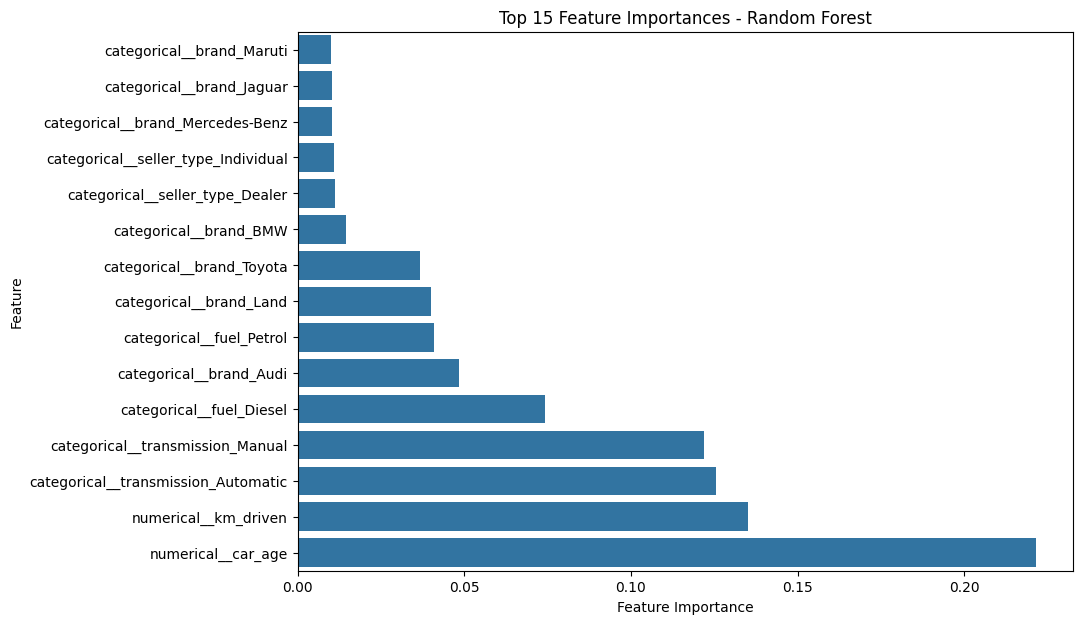

In [32]:
# Select the top 15 features
top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

# Create the feature importance plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

# Add title and axis labels
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

# Display the plot
plt.show()

## 28. Final Model Interpretation

In [33]:
# Display the final model interpretation
print("Final Model Interpretation")
print("-" * 30)

print(f"Best-Performing Model: {best_model_name}")

print(f"\nMAE: {random_forest_mae:.2f}")
print(f"RMSE: {random_forest_rmse:.2f}")
print(f"R² Score: {random_forest_r2:.4f}")

print("\nMost Important Features:")
display(importance_df.head(10))

Final Model Interpretation
------------------------------
Best-Performing Model: Random Forest Regressor

MAE: 158267.52
RMSE: 363457.66
R² Score: 0.5899

Most Important Features:


,Feature,Importance
41,numerical__car_age,0.221403
42,numerical__km_driven,0.135138
34,categorical__transmission_Automatic,0.125505
35,categorical__transmission_Manual,0.122073
28,categorical__fuel_Diesel,0.074373
1,categorical__brand_Audi,0.048357
30,categorical__fuel_Petrol,0.041013
13,categorical__brand_Land,0.040003
24,categorical__brand_Toyota,0.036876
2,categorical__brand_BMW,0.014460


### Interpretation

The Random Forest Regressor was selected as the best-performing model based on its overall evaluation across MAE, RMSE, and R² score. It achieved an MAE of 158,267.52, an RMSE of 363,457.66, and an R² score of 0.5899.

The feature importance analysis shows that car age is the most influential feature, followed by kilometers driven. Transmission type and fuel type also contribute significantly to the model's predictions. Several car brands have additional influence on the predicted selling price.

The R² score of 0.5899 indicates that the selected model explains approximately 59% of the variation in selling prices in the test dataset. The remaining variation may be influenced by factors not included in the dataset, such as specific car model, engine specifications, condition, location, and other market factors.

## 29. Conclusion

### Conclusion

This project developed a machine learning regression system for predicting the selling price of used cars using the Vehicle Dataset from Cardekho. The workflow included data inspection, missing-value verification, duplicate removal, categorical value standardization, feature engineering, exploratory data analysis, categorical encoding, and train-test splitting.

Three regression models were evaluated: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. Based on MAE, RMSE, and R² score, the Random Forest Regressor was selected as the best-performing model, achieving an MAE of 158,267.52, an RMSE of 363,457.66, and an R² score of 0.5899 on the test dataset.

Feature importance analysis showed that car age and kilometers driven were among the most influential features, while transmission, fuel type, and car brand also contributed to the prediction.

Overall, the project demonstrates how machine learning can be applied to used-car price prediction and highlights the importance of data cleaning, feature engineering, exploratory analysis, appropriate preprocessing, model comparison, and evaluation.